# Iranian Transactions - Data Cleaning & Exploratory Analysis

## 1. Objective

The goal of this notebook is to clean and standardize a deliberately corrupted  dataset before using it for exploratory data analysis

The dataset contains several intentional data-quality issues, including:

- inconsistent categorical labels
- spelling variations
- missing values
- negative transaction amounts
- zero-value transactions

The analysis is divided into two stages:

1. **Data Quality & Cleaning**
   - identify inconsistencies and missing values
   - standardize categorical variables
   - handle missing categorical observations
   - validate the cleaned dataset

2. **Exploratory Data Analysis**
   - transaction volume by city and card type
   - transaction success/failure patterns
   - card preferences across cities
   - temporal transaction patterns
   - transaction amount distributions

## 2. setup

Import the libraries required for data manipulation and visualization

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(
    style="whitegrid",context='notebook', palette="deep", font_scale=1.1, rc={"figure.figsize": (10, 6)}
)

## 3. Load and Inspect the Raw Dataset

In [4]:
df=pd.read_csv('./data/Iranian Transactions.csv')

In [5]:
print(f'dataset shape: {df.shape}')

dataset shape: (10000, 6)


In [6]:
df.sample(10, random_state=76)

,status,time,card_type,city,amount,id
5469,fail,2025-09-29 02:37:00,Visa,Tabriz,1.770500e+05,10
1847,failed,2025-09-29 11:11:00,Vsa,Tehran,1.305967e+06,34
6927,success,2025-09-13 21:21:00,Discover,Tehran,4.123080e+05,60
2843,fail,2025-09-27 03:27:00,NaN,Qom,1.000000e+10,65
7845,failed,2025-09-16 02:30:00,VISA,THR,2.050000e+05,43
6787,fail,2025-09-14 14:55:00,Discover,Tabriz,-9.999990e+05,85
3810,success,2025-09-05 06:06:00,Discover,Ahvaz,1.770500e+05,75
2039,Success,2025-09-30 07:07:00,Vsa,Tehran,1.502601e+06,9
2336,fail,2025-09-14 22:27:00,Visa,Qom,0.000000e+00,39
1316,success,2025-09-05 00:00:00,Amex,Tehran,1.578078e+06,50


## 4. Initial Data Audit

This **audity** dataframe shows missing values and their overall size in their respective column  

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   status     10000 non-null  str    
 1   time       10000 non-null  str    
 2   card_type  9689 non-null   str    
 3   city       9884 non-null   str    
 4   amount     10000 non-null  float64
 5   id         10000 non-null  int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 468.9 KB


In [8]:
df.describe(include='all')

,status,time,card_type,city,amount,id
count,10000,10000,9689,9884,1.000000e+04,10000.000000
unique,6,1724,10,14,NaN,NaN
top,fail,2025-09-29 11:11:00,Visa,Tehran,NaN,NaN
freq,3964,25,2358,2063,NaN,NaN
mean,NaN,NaN,NaN,NaN,2.954735e+08,50.061200
std,NaN,NaN,NaN,NaN,1.692035e+09,28.870875
min,NaN,NaN,NaN,NaN,-9.999990e+05,1.000000
25%,NaN,NaN,NaN,NaN,1.005000e+02,25.000000
50%,NaN,NaN,NaN,NaN,3.436790e+05,50.000000
75%,NaN,NaN,NaN,NaN,9.144650e+05,74.000000


In [9]:
audit = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean().mul(100).round(2),
    "unique": df.nunique()
}).sort_values("missing_%", ascending=False)

display(audit)

,dtype,missing,missing_%,unique
card_type,str,311,3.11,10
city,str,116,1.16,14
time,str,0,0.00,1724
status,str,0,0.00,6
amount,float64,0,0.00,52
id,int64,0,0.00,99


In [10]:
initial_shape = df.shape
initial_missing = df.isna().sum().sum()

## 5. Data Cleaning

Data cleaning part consists of :
 
* Standarization of content of columns by stripping off extra spaces and turning them lowercase 

* Replacment of alterating / errorous versions of values that are by logical point of view means the same or replacing misspelled values with intended ones

Examples :

* `succeed` -> `success`
* `master-card` -> `mastercard`
* `thran` -> `tehran`

### 5.1  Status

There are only 2 unique values (success , completed), the rest is just their altered versions

In [11]:
df['status'].unique()

<StringArray>
['success', 'fail', 'Success', 'failed', 'succeed', 'FAIL']
Length: 6, dtype: str

In [12]:
df['status']=(
    df['status']
    .str.lower()
    .str.strip()
    .replace(
        {
            "succeed":'success',
            "fail":'failed'
        }
    )
    .astype('category')
)

### 5.2 Time

In [13]:
df["time"]=pd.to_datetime(df['time'])

### 5.3 Card Type

The `card_type` column contains multiple representations of the same card type,
including capitalization differences, spacing variations, and misspellings.

For example:

- `Visa`, `visa`, `VISA`
- `MasterCard`, `Master-Card`, `Master Card`
- `Vsa`
- `MastCard`


The values are first normalized by:

1. converting text to lowercase
2. removing surrounding whitespace
3. replacing known erroneous labels with their canonical values

This reduces multiple representations to four standardized categories:

`visa`, `mastercard`, `amex`, and `discover`.


Missing card types are imputed using the observed categorical distribution rather
than the mode. This avoids assigning every missing observation to the most common
category.

In [14]:
df['card_type'].unique()

<StringArray>
[       'Visa',    'MastCard',    'Discover', 'Master-Card',        'Amex',
        'visa',  'MasterCard',           nan,         'Vsa',        'VISA',
 'Master Card']
Length: 11, dtype: str

In [15]:
df['card_type']=(
    df['card_type']
    .str.lower()
    .str.strip()
    .str.replace(' ','_')
    .replace(
        {
        'mastcard':'mastercard',
        'vsa':'visa',
        'master-card':'mastercard',
        'master_card':'mastercard'
        }
    )
    .astype('category')
)

In [16]:
rng=np.random.default_rng(1969)

In [17]:
card_type_probability=df['card_type'].value_counts(normalize=True)

missing_card_type=df['card_type'].isna()

df.loc[missing_card_type,'card_type'] = rng.choice(
    card_type_probability.index,
    size=missing_card_type.sum(),
    p=card_type_probability.values
)

### 5,4 City

`City` column faces similar problem as `Card_type` one. Those problems consists of capitalization differences, spacing variations, and misspellings

Similar Random categorical imputation using the observed empirical distribution was used as city distribution is heavily skewed

Simple mode imputation can artificially increase the dominance of the most common value, thus making it not the most viable option to fill missing values 


> **Note:** Random categorical imputation preserves the marginal distribution
> approximately, but it does not preserve relationships between city and other
> variables such as transaction status, card type, or transaction time

In [18]:
df['city'].unique()

<StringArray>
[ 'Tehran', 'Tehran ', 'Isfahan',  'Tabriz',  'Shiraz',  'TEHRAN',   'karaj',
   'Ahvaz',     'THR',     'Qom', 'Mashhad',  'tehr@n',   'Karaj',       nan,
   'ThRan']
Length: 15, dtype: str

In [19]:
df['city'].value_counts()

city
Tehran     2063
Tabriz     1368
Isfahan    1073
Mashhad     900
Shiraz      727
Qom         669
Karaj       642
Ahvaz       632
THR         409
TEHRAN      403
karaj       395
tehr@n      332
Tehran      192
ThRan        79
Name: count, dtype: int64

In [20]:
df['city']=(
    df['city']
    .str.lower()
    .str.strip()
    .replace(
        ['thr',"tehr@n",'thran'],
        'tehran'
    )
)


In [21]:
city_probability=df['city'].value_counts(normalize=True)

missing_city=df['city'].isna()

df.loc[missing_city,'city'] = rng.choice(
    city_probability.index,
    size=missing_city.sum(),
    p=city_probability.values
)

### 5.5 Amount

The `amount` column contains 1,204 negative values.

Because this dataset is explicitly described as containing corrupted transaction
amounts, negative values are treated as sign corruption and converted to their
absolute values

There are **981** values that are equal to 0. we can assume that those are transactions that failed, thus transfered amount is 0. but those with success status make no sense and should be dropped or filled with fitting value or at least be classified as nan instead of remaining 0 as it causes disturbtion in later analysis

>This assumption would not automatically be valid for a real financial dataset,
>where negative amounts may represent refunds, chargebacks, or
>account adjustments.

In [22]:
df['amount'].describe()

count    1.000000e+04
mean     2.954735e+08
std      1.692035e+09
min     -9.999990e+05
25%      1.005000e+02
50%      3.436790e+05
75%      9.144650e+05
max      1.000000e+10
Name: amount, dtype: float64

In [23]:
df['amount']=df['amount'].abs()

In [24]:
df[(df['amount']==0)]

,status,time,card_type,city,amount,id
3,success,2025-09-15 13:13:00,discover,isfahan,0.0,40
9,failed,2025-09-26 07:32:00,visa,tehran,0.0,82
28,success,2025-09-28 03:27:00,mastercard,shiraz,0.0,69
60,failed,2025-09-07 09:09:00,discover,qom,0.0,73
63,failed,2025-09-25 19:29:00,mastercard,tehran,0.0,96
...,...,...,...,...,...,...
9931,success,2025-09-13 01:51:00,mastercard,karaj,0.0,29
9935,success,2025-09-10 02:30:00,discover,tehran,0.0,80
9941,success,2025-09-21 16:16:00,visa,karaj,0.0,78
9951,success,2025-09-17 08:59:00,mastercard,tehran,0.0,83


In [25]:
false_succeeded_transactions=((df['amount']==0) & (df['status']=='success'))

In [26]:
df=df[~false_succeeded_transactions]

## 6. Post-Cleaning Validation

In [27]:
print("Shape:", df.shape)

display(
    pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isna().sum(),
        "missing_%": df.isna().mean().mul(100).round(2),
        "unique": df.nunique()
    })
)

Shape: (9546, 6)


,dtype,missing,missing_%,unique
status,category,0,0.0,2
time,datetime64[us],0,0.0,1721
card_type,category,0,0.0,4
city,str,0,0.0,8
amount,float64,0,0.0,50
id,int64,0,0.0,99


In [28]:
assert df["status"].notna().all()
assert df["card_type"].notna().all()
assert df["city"].notna().all()

assert (df["amount"].dropna() >= 0).all()

assert pd.api.types.is_datetime64_any_dtype(df["time"])

assert set(df["status"].unique()) <= {"success", "failed"}
assert set(df["card_type"].unique()) <= {"visa", "mastercard", "amex", "discover"}

expected_cities = {"tehran", "tabriz", "isfahan", "mashhad","shiraz", "qom", "karaj", "ahvaz"}

assert set(df["city"].unique()) <= expected_cities

## 7. Final Dataset

Display a sample and summarize the final schema

In [29]:
final_shape = df.shape
final_missing = df.isna().sum().sum()

print(f"Initial rows: {initial_shape[0]}")
print(f"Final rows:   {final_shape[0]}")
print(f"Rows removed: {initial_shape[0] - final_shape[0]}")

print(f"\nInitial missing values: {initial_missing}")
print(f"Final missing values:   {final_missing}")

Initial rows: 10000
Final rows:   9546
Rows removed: 454

Initial missing values: 427
Final missing values:   0


| Column      | Issue                        | Action                        | 
| ----------- | ---------------------------- | ----------------------------- | 
| `status`    | inconsistent labels          | standardized values           | 
| `time`      | string dtype                 | converted to datetime         | 
| `card_type` | spelling/case variations     | standardized                  | 
| `card_type` | 311 missing                  | distribution-based imputation | 
| `city`      | spelling/case variations     | standardized                  | 
| `city`      | 116 missing                  | distribution-based imputation | 
| `amount`    | negative values              | absolute value                | 
| `amount`    | zero successful transactions | removed                       | 

## 8. Data Analysis

### Q1 : Which city has the highest number of transactions

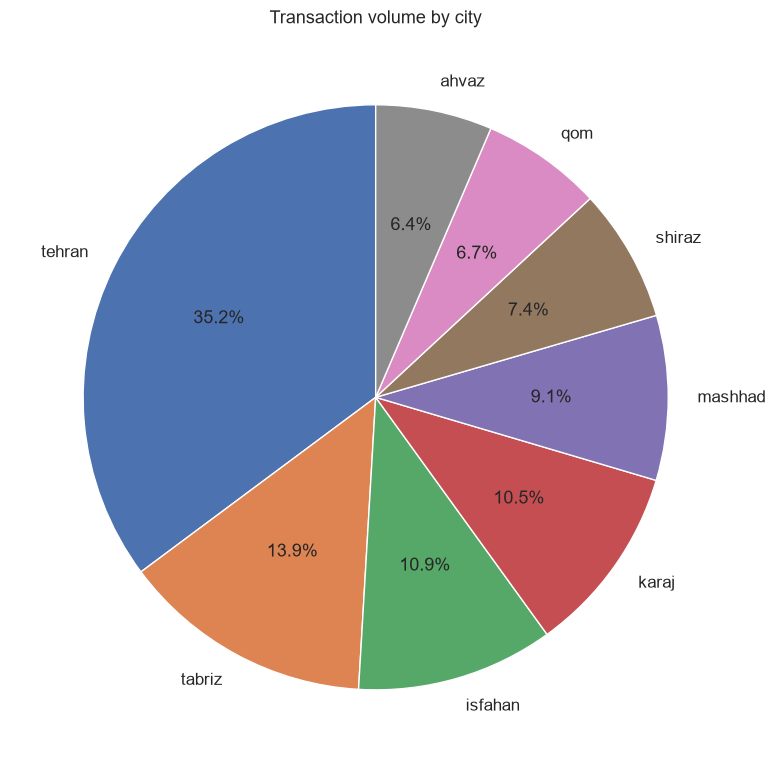

In [30]:
fig,ax=plt.subplots(figsize=(8,8))

city_transaction_amount=df['city'].value_counts()

ax.pie(
    city_transaction_amount,
    labels=city_transaction_amount.index,
    autopct="%1.1f%%",
    startangle=90,
)

ax.set_title('Transaction volume by city')
plt.tight_layout()


### Q2 : Which card types are most frequently used?

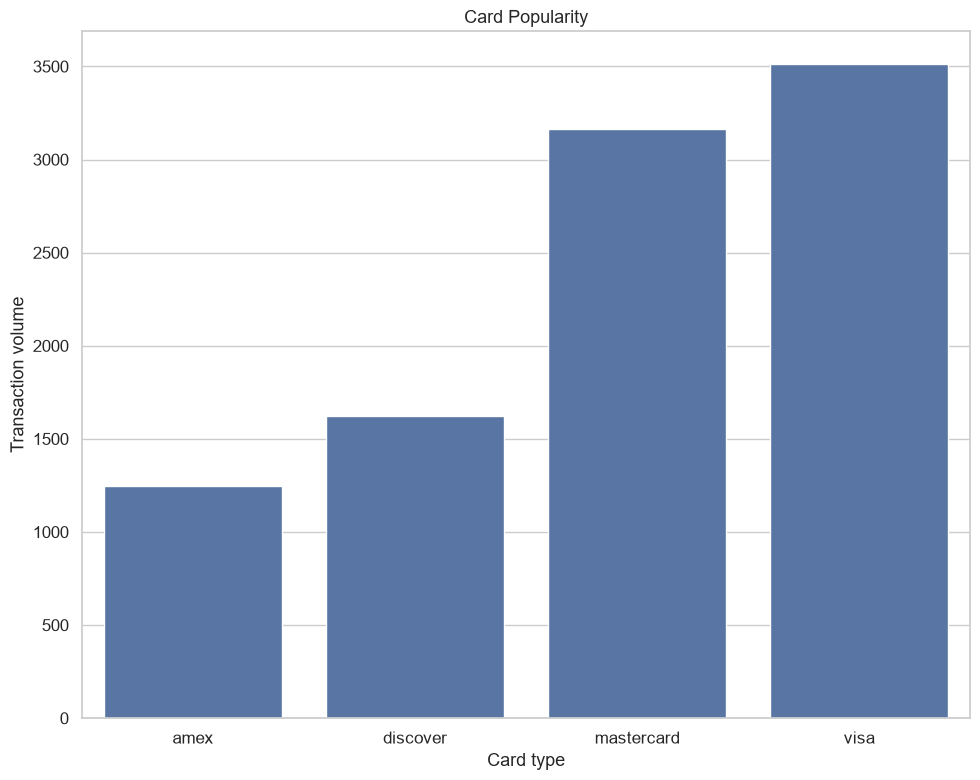

In [31]:
card_popularity=df['card_type'].value_counts().reset_index()

fig,ax=plt.subplots(figsize=(10,8))

sns.barplot(
    data=card_popularity,
    x='card_type',
    y='count',
    ax=ax
)

ax.set_title('Card Popularity')
ax.set_xlabel("Card type")
ax.set_ylabel("Transaction volume")

plt.tight_layout()

### Q3 : What card if the most preferable in each city 

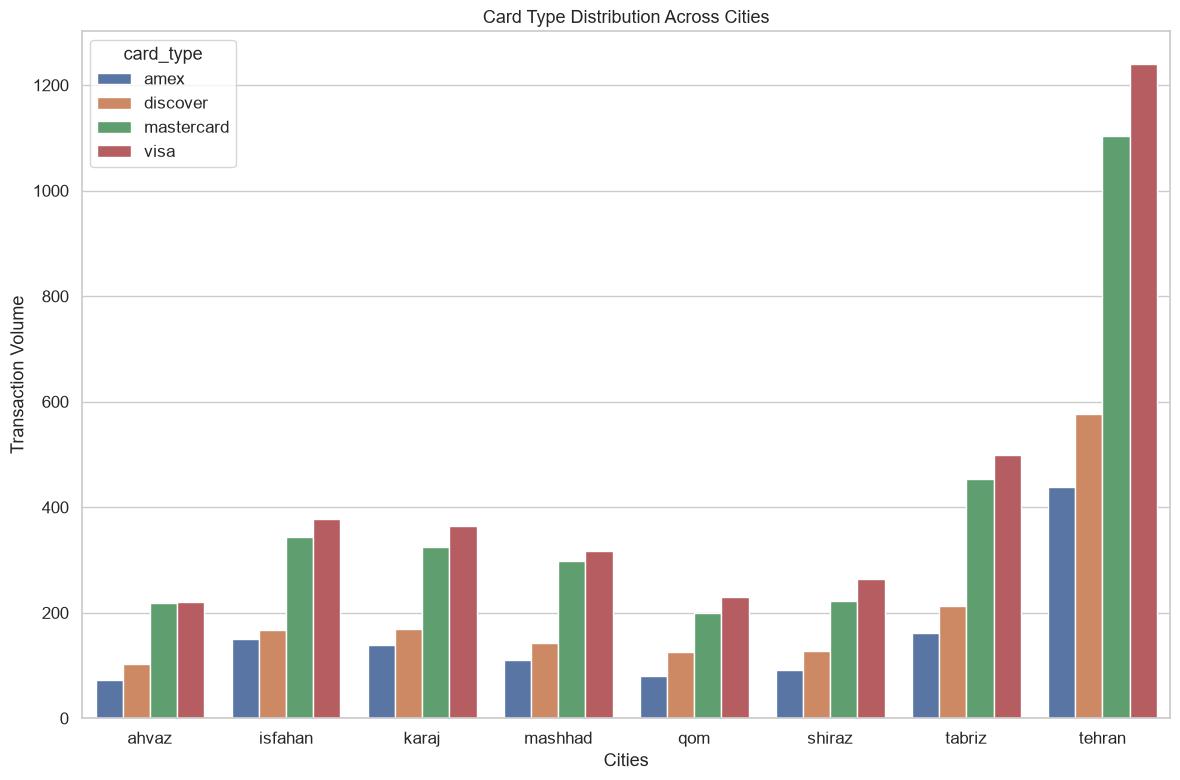

In [32]:
favourite_card=df.groupby('city')["card_type"].value_counts().reset_index()

fig,ax=plt.subplots(figsize=(12,8))

sns.barplot(
    data=favourite_card,
    x='city',
    y='count',
    hue='card_type'
)

plt.title('Card Type Distribution Across Cities')
plt.xlabel('Cities')
plt.ylabel('Transaction Volume')
plt.tight_layout()

### Q4 : Does transaction success rate differ by card type?

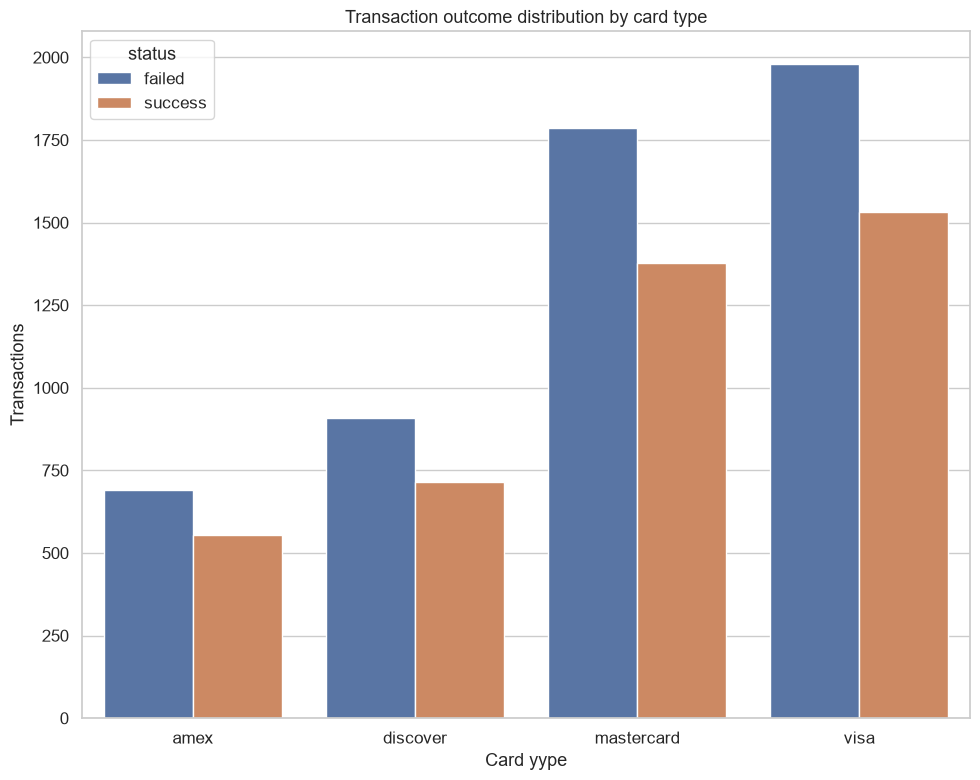

In [33]:
card_transaction_status=df.groupby('card_type')['status'].value_counts().reset_index()

fig,ax=plt.subplots(figsize=(10,8))

sns.barplot(
    data=card_transaction_status,
    x='card_type',
    y='count',
    hue='status',
    ax=ax
)

ax.set_title("Transaction outcome distribution by card type")
ax.set_xlabel('Card yype')
ax.set_ylabel('Transactions')

plt.tight_layout()

### Q5: Does transaction amount differ between successful and failed transactions?

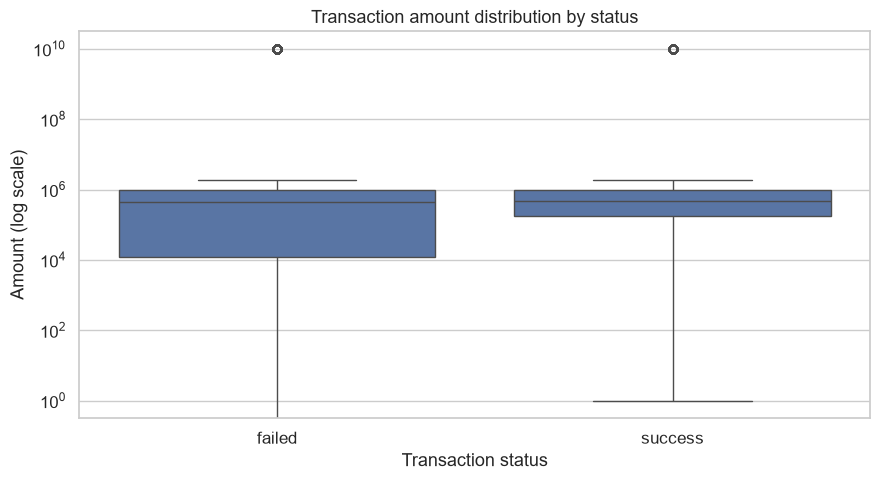

In [34]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="status",
    y="amount"
)

plt.yscale("log")
plt.title("Transaction amount distribution by status")
plt.xlabel("Transaction status")
plt.ylabel("Amount (log scale)")
plt.tight_layout()

### Q6 : When was transaction volume highest ?

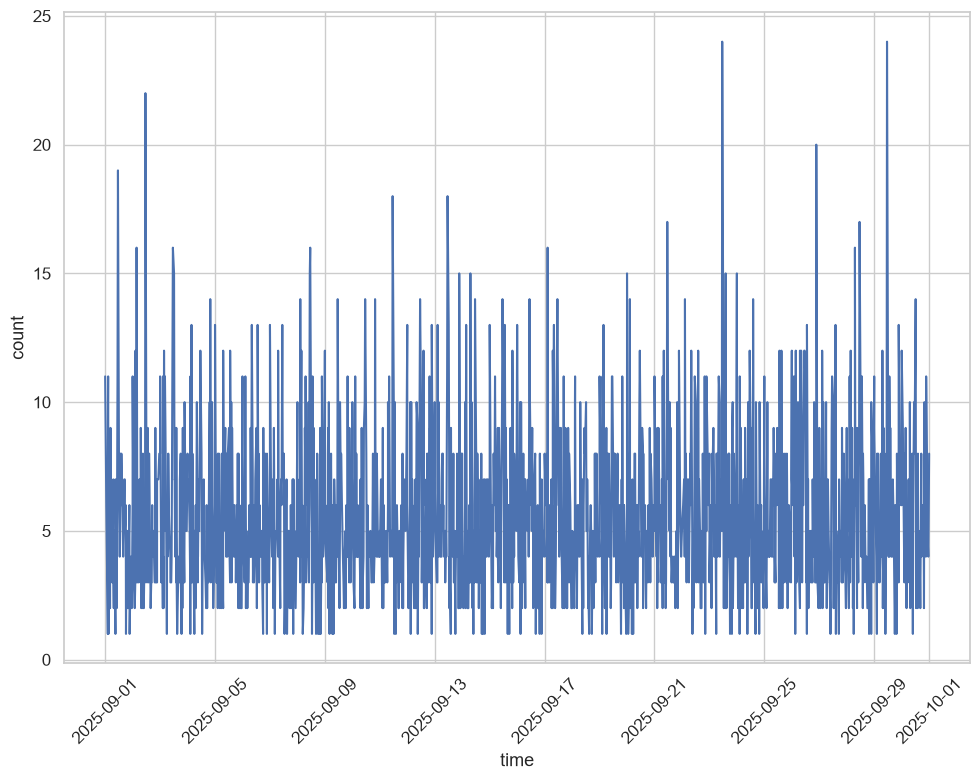

In [35]:
transaction_hist_per_card=df.groupby('time')['card_type'].value_counts().reset_index()

total=transaction_hist_per_card.groupby('time')['count'].sum().reset_index()

fig,ax=plt.subplots(figsize=(10,8))


sns.lineplot(
    data=total,
    x='time',
    y='count',
    errorbar=None
)

plt.xticks(rotation=45)
plt.tight_layout()

### Q7 : When do people transact?

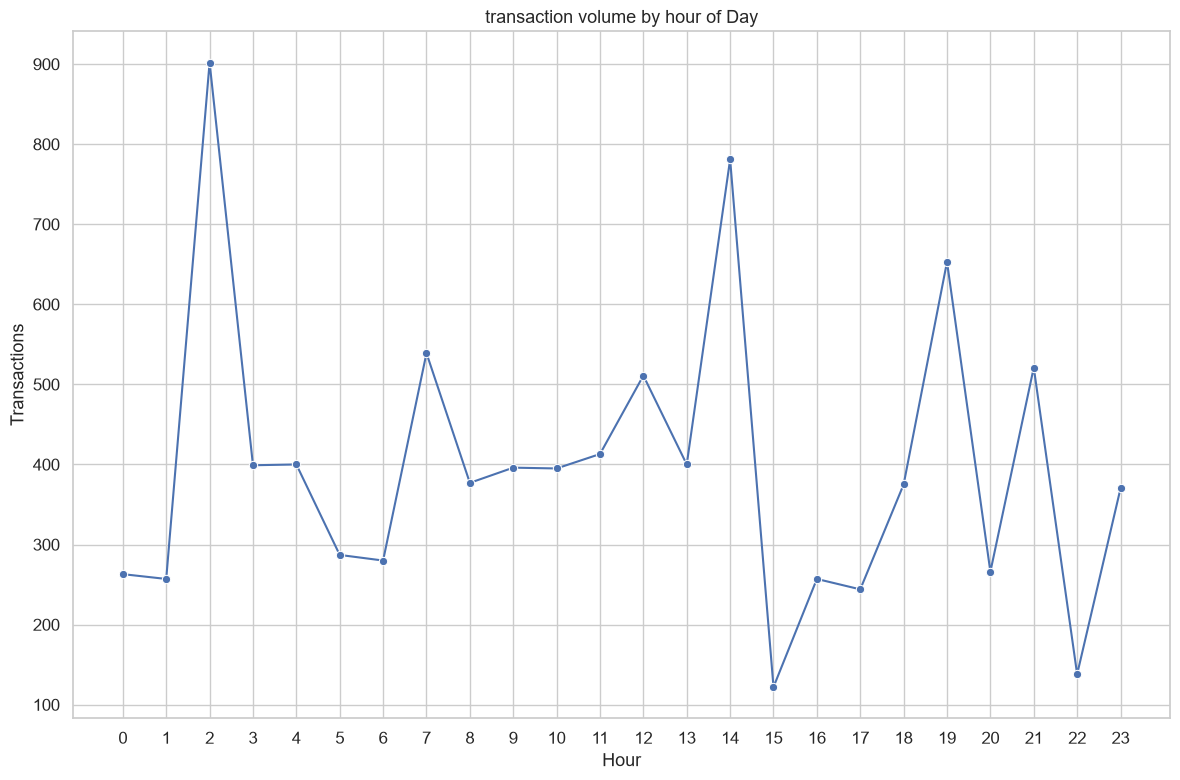

In [36]:
hourly_transactions=(
    df['time'].dt.hour
    .value_counts()
    .sort_index()
    .reset_index()
)

fig,ax=plt.subplots(figsize=(12,8))

sns.lineplot(
    data=hourly_transactions,
    x="time",
    y="count",
    marker="o"
)

plt.title("transaction volume by hour of Day")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.xticks(ticks=range(0,24,1))
plt.tight_layout()

### Q8: What is the busiest Weekday × Hour tranaction volume

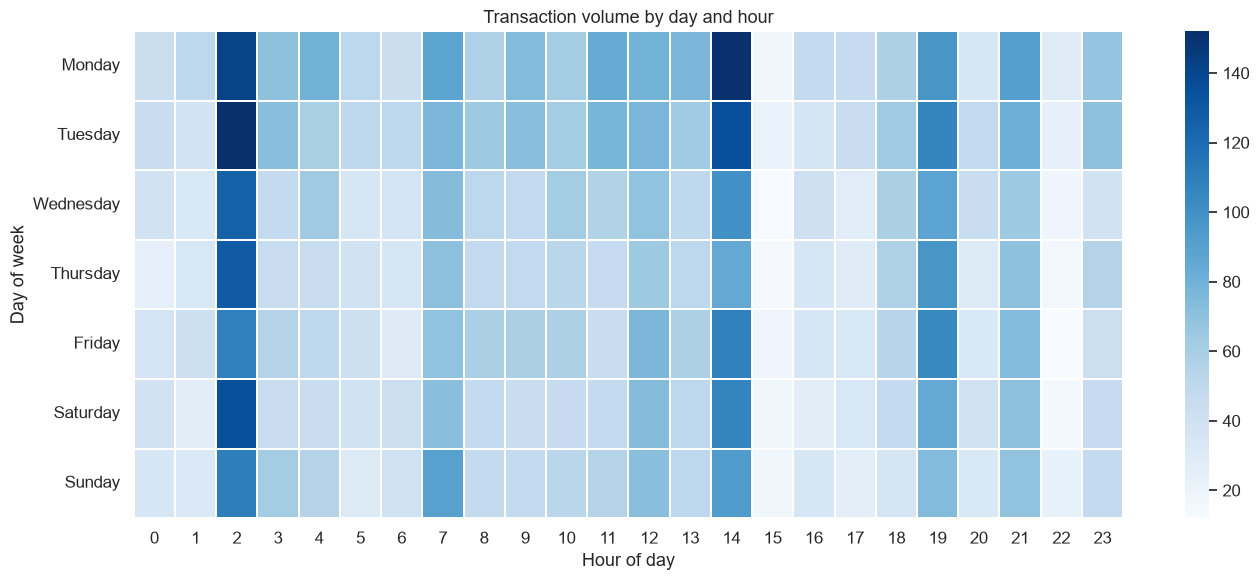

In [37]:
hour_day = pd.crosstab(
    df['time'].dt.day_name(),
    df['time'].dt.hour
)

week_day_order = [
    "Monday",
    "Tuesday", 
    "Wednesday",
    "Thursday", 
    "Friday", 
    "Saturday", 
    "Sunday"
]

hour_day = hour_day.reindex(week_day_order)

plt.figure(figsize=(14, 6))

sns.heatmap(
    hour_day,
    cmap="Blues",
    linewidths=.2
)

plt.title("Transaction volume by day and hour")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.tight_layout()

# 9. Key Findings

### Transaction Geography
- Tehran accounts for the largest share of transactions
- Tabriz is the second-largest transaction location

### Card Usage
- Visa is the most frequntly used card type
- Mastercard is the second most common card type
- Card preferences vary somewhat across cities

### Transaction Outcomes
- Transaction success rates differ across card types/cities
- Raw transaction counts should not be confused with success rates

### Temporal Patterns
- Transaction activity varies throughout the day
- Daily/hourly aggregation provides a clearer picture than plotting individual
  transaction timestamps.

### Data Quality
- The raw dataset contained inconsistent categorical labels and missing values.
- Standardization reduced multiple erroneous representations to canonical values.
- Distribution-based imputation was used for missing categorical observations.

## Limitations

This dataset appears to be synthetic and intentionally corrupted. Therefore,
patterns identified in this analysis should be interpreted as characteristics
of the dataset rather than evidence about real-world Iranian financial behavior

The categorical imputation strategy preserves the approximate marginal
distribution but does not account for relationships between variables